# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Githa Harlaar
* Username: gharlaar
* Student number: s6396186
* Group (AS1, etc.): AS5

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

In [2]:
from scipy.constants import pi
from IPython.display import display, Math
from math import *
import numpy as np

L = 1.00  #m
errL = 0.01  #m
T = 2.01  #s
errT = 0.02  #s

g = (4*pi**2 *L)/T**2
print(f"So the calculated value for g is {g}.")


#Error using Tyler expansion

display(Math(r'\frac{\partial g}{\partial L} = \frac{4\pi^2}{T^2}'))
display(Math(r'\frac{\partial g}{\partial T} = -\frac{8\pi^2 L}{T^3}'))
display(Math(r'\Delta g = \sqrt{(\frac{4\pi^2}{T^2}\Delta L)^2 +(-\frac{8\pi^2 L}{T^3}\Delta T)^2}'))

errg = sqrt(((4*pi**2/T**2)*errL)**2 + ((-8*pi**2*L/T**3)*errT)**2)

print(f"The error of g using the Taylor expansion is {errg} meters per second squared.")



#Calculating the error using Monte Carlo

#Creating the Gaussian distributions
#From PLS, I assume these errors hava a Gaussian distribution

datapoints = 10000
L_distribution = np.random.normal(L, errL, datapoints)
T_distribution = np.random.normal(T, errT, datapoints)
g_mc = (4*pi**2 *L_distribution)/T_distribution**2 #calculating the new g values
g_mc_mean = np.mean(g_mc)  #calculating the average new g
g_mc_stdev = np.std(g_mc)  #calculating the standard deviation of the new g
print()
print(f'The value and error of g using Monte Carlo is{g_mc_mean} ± {g_mc_stdev} meters per second squared.')

So the calculated value for g is 9.77164367326488.


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

The error of g using the Taylor expansion is 0.2176313753358241 meters per second squared.

The value and error of g using Monte Carlo is9.778680813168137 ± 0.21743721048310297 meters per second squared.


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [4]:
import numpy as np
from IPython.display import display, Math

equation = display(Math(r'{a} x^2 + {b} x + {c}'))  #Printing the equation


#Getting the constants 

a = float(input("Enter a value for a: "))
b = float(input("Enter a value for b: "))
c = float(input("Enter a value for c: "))


# Calculating the roots

D = complex(b**2 - 4*a*c)
x1 = (-b + np.sqrt(D))/(2*a)
x2 = (-b - np.sqrt(D))/(2*a)

print()
print(f"So the complex solutions to the equation above with constants {a}, {b} and {c} are {x1} and {x2}. ")
print()

#Proving f(x) = 0

f1 = a*x1**2 + b * x1 + c
f2 = a*x2**2 + b * x2 + c

print(f'If you put x1 back into the equation, it gives {f1}.')
print(f'If you put x2 back into the equation, it gives {f2}.')
print(f'These values are approximately equal to zero.')

<IPython.core.display.Math object>

Enter a value for a:  1
Enter a value for b:  2
Enter a value for c:  3



So the complex solutions to the equation above with constants 1.0, 2.0 and 3.0 are (-1+1.4142135623730951j) and (-1-1.4142135623730951j). 

If you put x1 back into the equation, it gives (-4.440892098500626e-16+0j).
If you put x2 back into the equation, it gives (-4.440892098500626e-16+0j).
These values are approximately equal to zero.


In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

The area between x=0 and x=2.5 with its according error is 1.9769788548675902, 2.1948874438710744e-14.


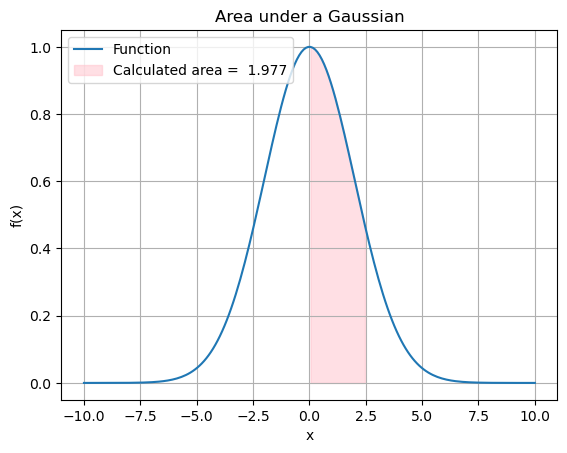

The area between infinities with its according error is (5.013256549262001, 6.333282282770592e-09).
This result, True, gave that both sides of the equations are approximately equal.


In [6]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import quad

#Defining the function, constants and variables

def gauss(x, A, x0, sig, z0):
    return A*np.exp(-(x-x0)**2/(2*sig**2))+z0
    
A = 1.0
x0 = 0.0
sig = 2.0
z0 = 0.0

x = np.linspace(-10, 10, 200)
y = gauss(x, A, x0, sig, z0)  #values for the given x


#Plotting the function

plt.plot(x, y, label = 'Function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Area under a Gaussian')
plt.grid(True)


# Finding the area using quad()
x_low = 0
x_up = 2.5
area, error = scipy.integrate.quad(gauss, x_low, x_up, args = ( A, x0, sig, z0))
print(f"The area between x=0 and x=2.5 with its according error is {area}, {error}.")

plt.fill_between(x, y, where=(x >= x_low) & (x <= x_up), color = 'pink', alpha = 0.5, label = f'Calculated area = {area: .3f}')


# Showing the plot

plt.legend()
plt.show()


#Finding the area between infinities
area_inf = scipy.integrate.quad(gauss, -np.inf, np.inf , args = ( A, x0, sig, z0))

print(f"The area between infinities with its according error is {area_inf}.")



#Calculating the total area of the graph

def gausstotalarea(x, A, x0, sig):
    return A*np.exp(-(x-x0)**2/(2*sig**2))

total_area_left, error = scipy.integrate.quad(gausstotalarea,-np.inf, np.inf , args = ( A, x0, sig))

total_area_right = A * sig * np.sqrt(2*np.pi)

#total_area_left == total_area_right doesnt work due to tiny, tiny deviations

equalornot = np.isclose(total_area_left, total_area_right)  #Gives if both sides are equal

print(f"This result, {equalornot}, gave that both sides of the equations are approximately equal.")





#make into executable script

For in the the entered values 1, 2, 3, 4, 5 and 6 (in order of input), the generated graph is this:
Link to GitHub: https://github.com/gharlaar/PROGNUM-repo.git

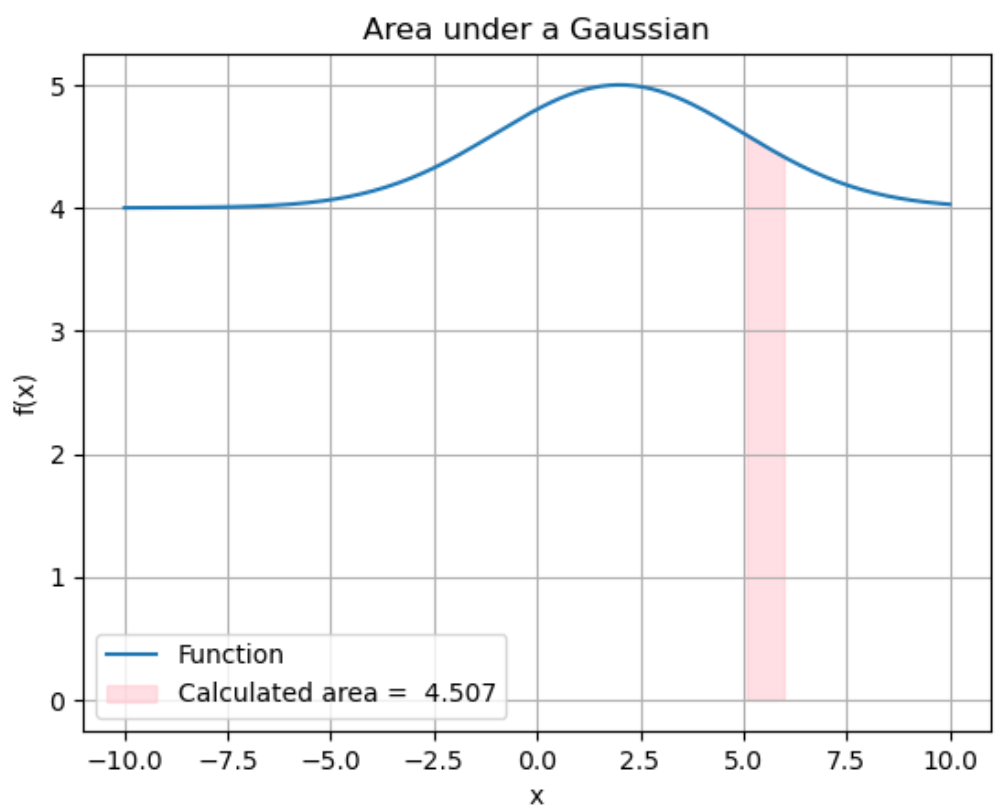

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [19]:
import numpy as np
from numpy import sin, cos, pi, exp
import scipy
from scipy.integrate import quad

#defining the function

function= input("Enter a function: ") 
def f(x):
    try: 
        return eval(function) 
    except NameError:
        print(f"Unknown function or variable used.")
    except SyntaxError:
        print (f"Invalid syntax used.")
    except IndexError:
        print(f"The sequence subscript is out of range.")
    except TypeError:
        print(f"An operation or function is applied to an object of inappropriate type.")
    except ValueError:
        print(f"An operation or function recieved an argument of the right type but it has an inappropriate value.")
    except Exception as exc:
        print(f"Error in evaluating the expression: {exc}.")
    
#Defining the bounds of the integrals
x_low = 0
x_up = pi

#Calculating the integral using quad
area = scipy.integrate.quad(f, x_low, x_up)
print(f"So the area and its error calculated using the quad function is {area}.")

#Calculating the error using Monte Carlo
#Creating the Gaussian distributions
#From PLS, I assume these errors hava a Gaussian distribution
N = 100000
def MonteCarlo(f, x_low, x_up, N):
    try:
        x = np.random.uniform(0, pi, N)
        y = np.array([f(xi) for xi in x])
        integral = (x_up - x_low) * np.mean(y)
        error = ((x_up - x_low) * np.std(y)) / np.sqrt(N)
    
        return integral, error
    except NameError:
        print(f"Unknown function or variable used.")
    except SyntaxError:
        print (f"Invalid syntax used.")
    except IndexError:
        print(f"The sequence subscript is out of range.")
    except TypeError:
        print(f"An operation or function is applied to an object of inappropriate type.")
    except ValueError:
        print(f"An operation or function recieved an argument of the right type but it has an inappropriate value.")
    except Exception as exc:
        print(f"Error in evaluating the expression: {exc}.")
    
area_MonteCarlo = MonteCarlo(f, x_low, x_up, N)
print(f"The area and its error determined by using Monte Carlo is {area_MonteCarlo}.")
 #This could change a bit every time, but it is roughly the same


Enter a function:  x**4 + exp(sin(x) + cos(x))


So the area and its error calculated using the quad function is (68.72932272689113, 8.854230135489868e-10).
The area and its error determined by using Monte Carlo is (np.float64(68.69773800437513), np.float64(0.24639515147203525)).


In [9]:
import sympy as sp

x = sp.Symbol('x')  #defining x

f = x**4 + sp.exp(sp.sin(x) + sp.cos(x))  #defining the formula
integral = sp.integrate(f, (x, 0, sp.pi))  #calculating the integral
integral_value = integral.evalf()  #Evaluating the value of the integral

print(f"So the value of the integral is {integral_value}.")

So the value of the integral is 68.7293227268911.


GitHub link: https://github.com/gharlaar/PROGNUM-repo.git

In [10]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

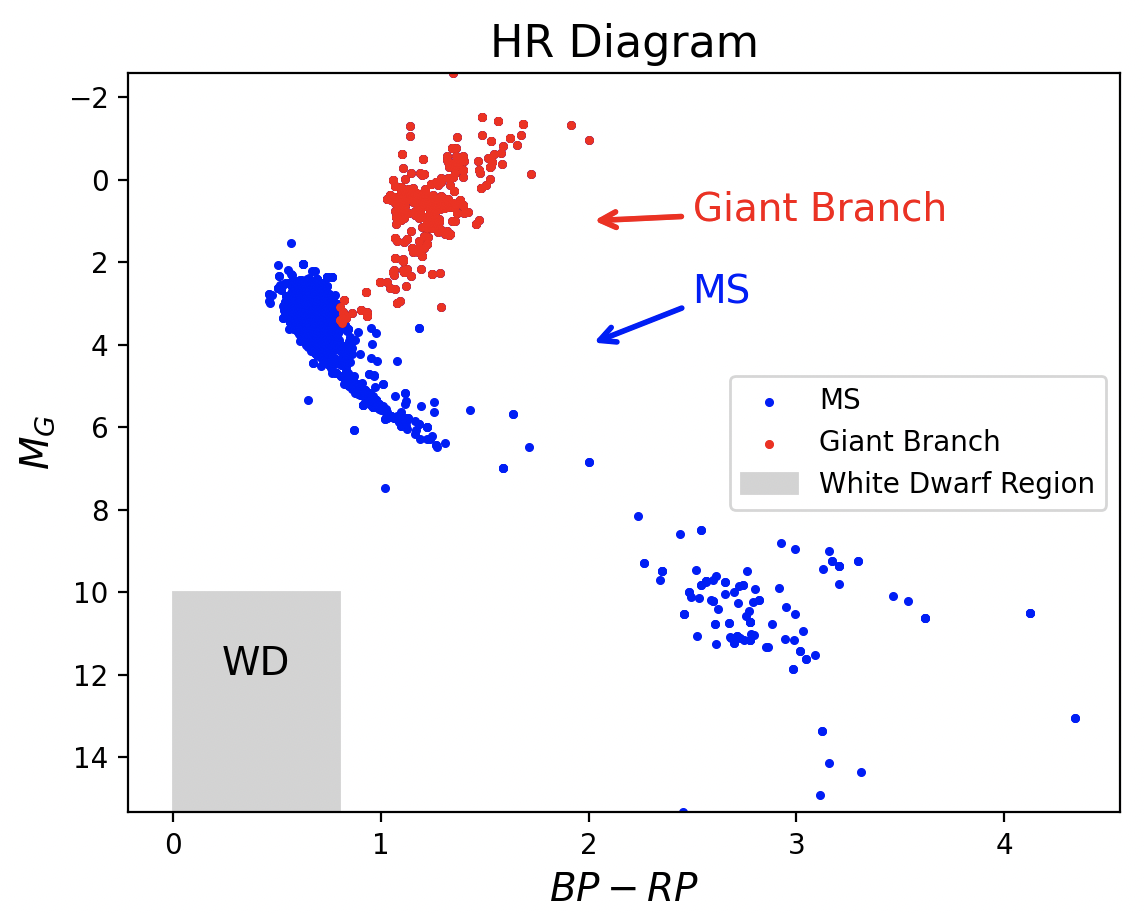

168133 stars have good quality measurements.


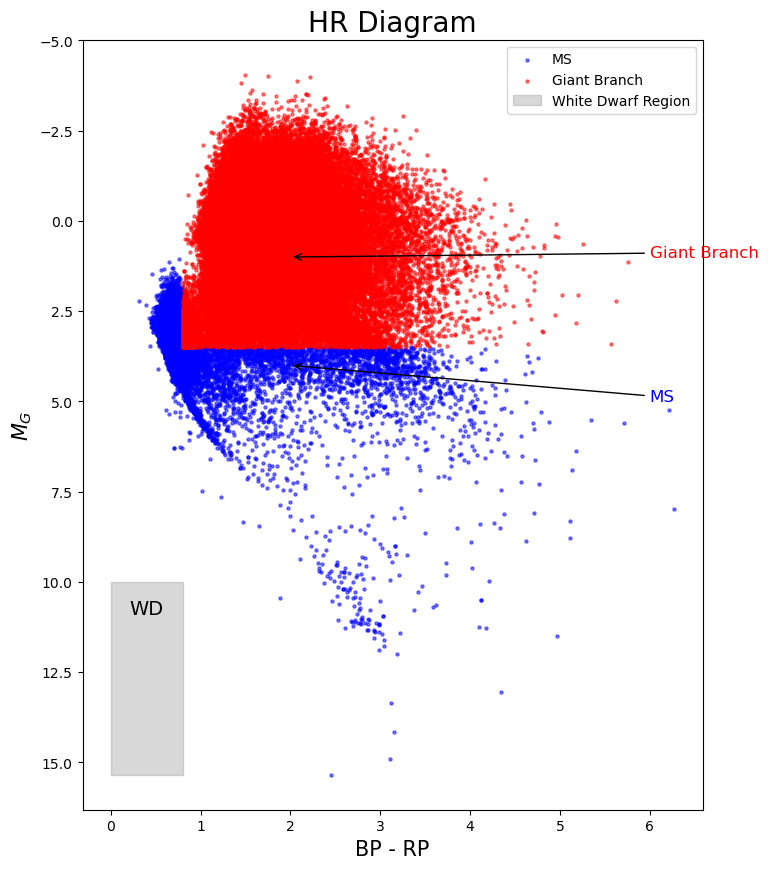

In [11]:
#ChatGPT was used for this, since at the beginning of the section it was said that we could use it
#But, I did try to understand every part of the code
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

#Applying the cuts
mask = ((data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    ~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG']) &
    ~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG']) &
    ~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))

clean_data = data[mask]
print(f"{len(clean_data)} stars have good quality measurements.")

#Randomly select 80% of the data
np.random.seed(42)  # To make sure it's always the same 80%
indices = np.random.choice(len(clean_data), size=int(0.8*len(clean_data)), replace=False)
sample = clean_data[indices]

#Calculating the absolute magnitude
## M_G = G - 5 * log10(parallax/1000) + 5, where distance = 1000 / parallax in mas

parallax_mas = sample['GAIAEDR3_PARALLAX']
distance_pc = 1000.0 / parallax_mas
abs_mag_G = sample['GAIAEDR3_PHOT_G_MEAN_MAG'] + 5*np.log10(parallax_mas/1000) + 5


#Finding the BP-RP color
color_bp_rp = sample['GAIAEDR3_PHOT_BP_MEAN_MAG'] - sample['GAIAEDR3_PHOT_RP_MEAN_MAG']

# Rough classification
giant_mask = (abs_mag_G < 3.5) & (color_bp_rp > 0.8)
ms_mask = ~giant_mask  # everything else



#Plotting the HR diagram
plt.figure(figsize=(8, 10))
plt.scatter(color_bp_rp[ms_mask], abs_mag_G[ms_mask], s=5, c='blue', alpha=0.5, label='MS')
plt.scatter(color_bp_rp[giant_mask], abs_mag_G[giant_mask], s=5, c='red', alpha=0.5, label='Giant Branch')

#Plotting the box
plt.fill_betweenx(y=[10, max(abs_mag_G)], x1=0, x2=0.8, color='grey', alpha=0.3, label='White Dwarf Region')
plt.text(0.4, 11, 'WD', color = 'black', fontsize = 14, ha = 'center', va = 'bottom') #ha and va align the text

#Plotting the arrows
plt.annotate('MS',
             xy=(2.0, 4),             # point to annotate (MS location)
             xytext=(6, 5),         # text location
             arrowprops=dict(facecolor='blue', arrowstyle='->'),
             fontsize=12, color='blue')
plt.annotate('Giant Branch',
             xy=(2, 1),             # point to annotate (GB location)
             xytext=(6, 1),         # text location
             arrowprops=dict(facecolor='red', arrowstyle='->'),
             fontsize=12, color='red')
#If I made it exactly as the plot in the exercise, you wouldn't be able to see the arrows




plt.gca().invert_yaxis()  # HR diagram convention: brighter stars at top
plt.xlabel('BP - RP', fontsize = 15)
plt.ylabel(r'$M_G$', fontsize = 15)
plt.title('HR Diagram', fontsize = 20)
plt.legend()
plt.show()

168133 stars have good quality measurements.


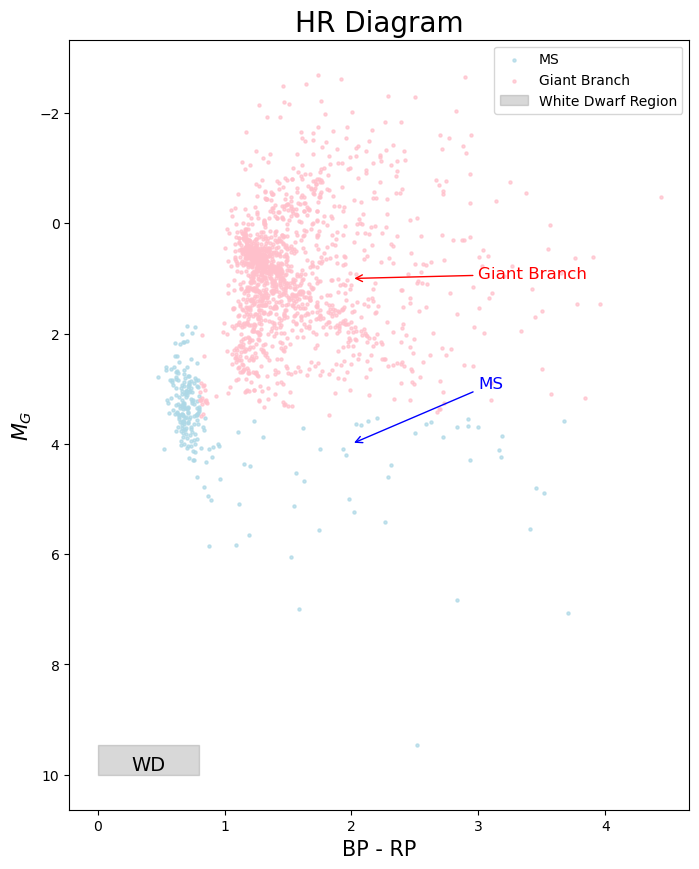

In [12]:
#ChatGPT was used for this, since at the beginning of the section it was said that we could use it
#But, I did try to understand every part of the code

#This code uses less data, so that it is clearer
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

#Applying the cuts
mask = ((data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    ~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG']) &
    ~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG']) &
    ~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))

clean_data = data[mask]
print(f"{len(clean_data)} stars have good quality measurements.")

#Randomly select 80% of the data
np.random.seed(42)  # To make sure it's always the same 80%
indices = np.random.choice(len(clean_data), size=int(0.01*len(clean_data)), replace=False)
sample = clean_data[indices]

#Calculating the absolute magnitude
## M_G = G - 5 * log10(parallax/1000) + 5, where distance = 1000 / parallax in mas

parallax_mas = sample['GAIAEDR3_PARALLAX']
distance_pc = 1000.0 / parallax_mas
abs_mag_G = sample['GAIAEDR3_PHOT_G_MEAN_MAG'] + 5*np.log10(parallax_mas/1000) + 5


#Finding the BP-RP color
color_bp_rp = sample['GAIAEDR3_PHOT_BP_MEAN_MAG'] - sample['GAIAEDR3_PHOT_RP_MEAN_MAG']

# Rough classification
giant_mask = (abs_mag_G < 3.5) & (color_bp_rp > 0.8)
ms_mask = ~giant_mask  # everything else



#Plotting the HR diagram
plt.figure(figsize=(8, 10))
plt.scatter(color_bp_rp[ms_mask], abs_mag_G[ms_mask], s=5, c='lightblue', alpha=0.7, label='MS')
plt.scatter(color_bp_rp[giant_mask], abs_mag_G[giant_mask], s=5, c='pink', alpha=0.7, label='Giant Branch')

#Plotting the box
plt.fill_betweenx(y=[10, max(abs_mag_G)], x1=0, x2=0.8, color='grey', alpha=0.3, label='White Dwarf Region')
plt.text(0.4, 10, 'WD', color = 'black', fontsize = 14, ha = 'center', va = 'bottom') #ha and va align the text

#Plotting the arrows
plt.annotate('MS',
             xy=(2.0, 4),             # point to annotate (MS location)
             xytext=(3, 3),         # text location
             arrowprops=dict(color='blue', arrowstyle='->'),
             fontsize=12, color='blue')
plt.annotate('Giant Branch',
             xy=(2, 1),             # point to annotate (GB location)
             xytext=(3, 1),         # text location
             arrowprops=dict(color = 'red', arrowstyle='->'),
             fontsize=12, color='red')




plt.gca().invert_yaxis()  # HR diagram convention: brighter stars at top
plt.xlabel('BP - RP', fontsize = 15)
plt.ylabel(r'$M_G$', fontsize = 15)
plt.title('HR Diagram', fontsize = 20)
plt.legend()
plt.show()


In [13]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")